In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Affine arithmetic library
import affapy as af
from affapy.aa import Affine
from affapy.ia import Interval

Let's explore the difference between AA and IA on simple examples. First, let's start out with the following function:

$$
f(x) = x^{2}
$$

where $x$ is an interval. Let's say that the entire domain goes from -1 to 1. We will subdivide the interval into smaller subintervals

In [61]:
# def eval_f(x):
#     try:
#         return (x.sin()**2*x.cos() - 4) / x.sqrt()
#     except:
#         return (np.sin(x)**2*np.cos(x) - 4) / np.sqrt(x)
    
def eval_f(x):
    try:
        return 1/(1 - x + x**2)
    except:
        return 1/(1 - x + x**2)

[0.032258064516129, 0.0487804878048781]
[0.0476190476190476, 0.08]
[0.0769230769230769, 0.153846153846154]
[0.142857142857143, 0.4]
[0.333333333333333, 2.0]
[1.0, 2.0]
[0.333333333333333, 2.0]
[0.142857142857143, 0.4]
[0.0769230769230769, 0.153846153846154]
[0.0476190476190476, 0.08]


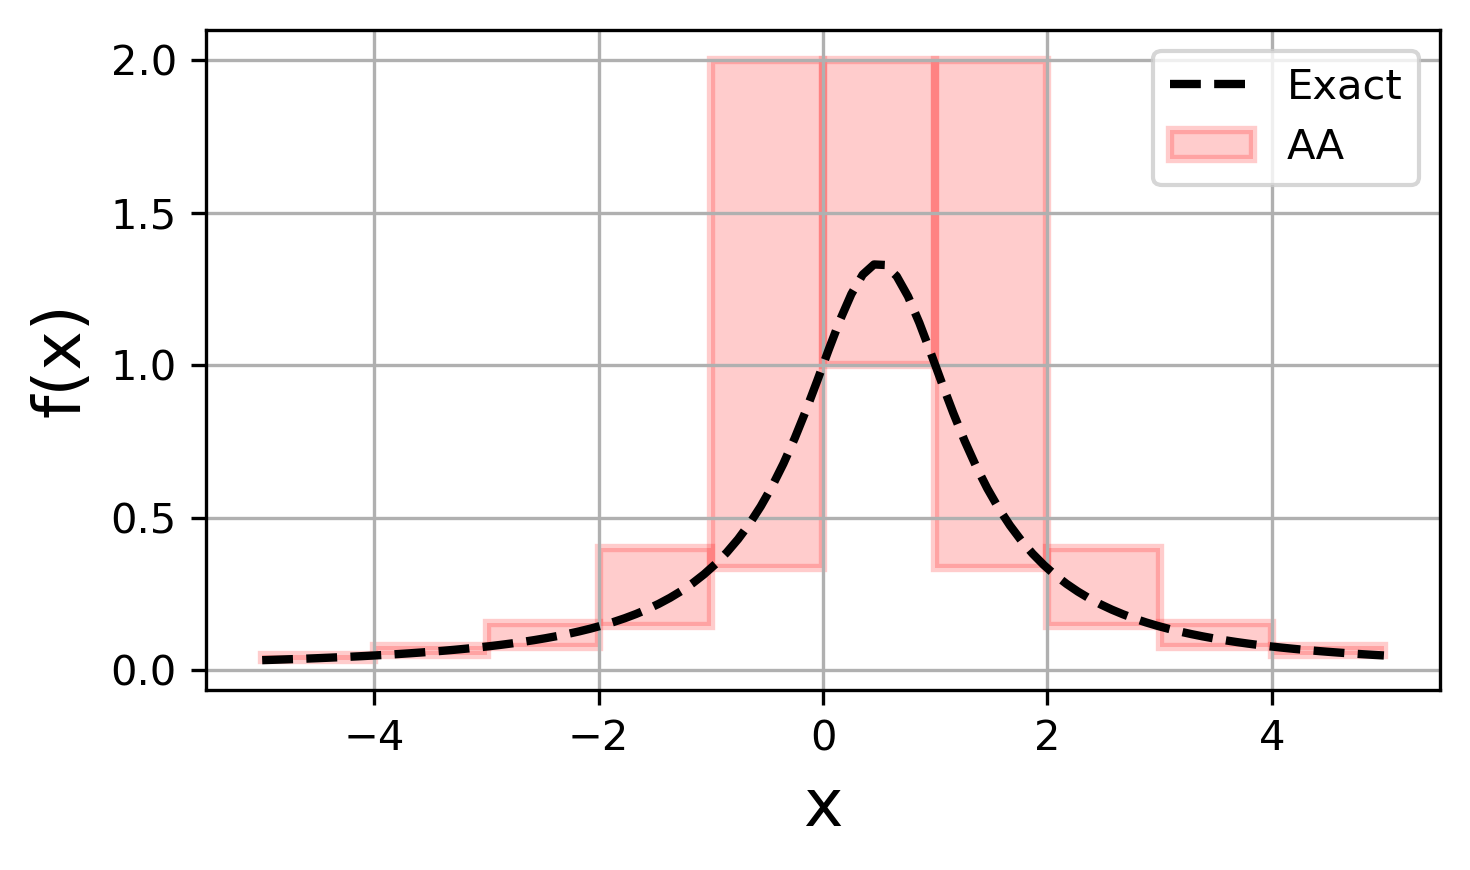

In [65]:
x_lower, x_upper = -5, 5
boxn = 10
npts = 100
width = (x_upper - x_lower) / boxn    # width of a box

x = np.linspace(x_lower, x_upper, npts)
y = eval_f(x)

fig, ax = plt.subplots(1, dpi=300, figsize=(5,3))

plt.plot(x, y, 'k--', linewidth=2, label='Exact')

for i in range(boxn):
    x1 = x_lower + i*width
    x2 = x1 + width
    xc = (x1 + x2) / 2

    # AA
    u = Affine([x1, x2])
    v = eval_f(u)

    itv = v.interval
    print(itv)
    if i == 0:
        rect = Rectangle((x1, itv.inf), width, itv.width(),
                            alpha=0.2, linewidth=2, color='r', label='AA')
    else:
        rect = Rectangle((x1, itv.inf), width, itv.width(),
                            alpha=0.2, linewidth=2, color='r')
    ax.add_patch(rect)

    # IA
    # u = Interval(x1, x2)
    # v = eval_f(u)
    # print(v)
    # if i == 0:
    #     rect = Rectangle((x1, v.inf), width, v.width(),
    #                         alpha=0.2, linewidth=2, color='b', label='IA')
    # else:
    #     rect = Rectangle((x1, v.inf), width, v.width(),
    #                         alpha=0.2, linewidth=2, color='b')
    # ax.add_patch(rect)

plt.xlabel('x', fontsize=16)
plt.ylabel('f(x)', fontsize=16)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [57]:
x =  Affine([1, 2])
y =  Affine([3, 4])

z = x*y
z.interval

Interval(2.5, 8.0)

In [58]:
x = Interval(1, 2)
y = Interval(3, 4)
z = x*y
z

Interval(3.0, 8.0)